Overall Customer Churn Rate: 28.50%

--- Churn Rate by Contract Type ---
Contract
Month-to-month    42.656250
One year          17.142857
Two year           6.122449
Name: Churn, dtype: float64


C:\Users\ramesh\AppData\Local\Temp\ipykernel_19776\3117481496.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ramesh\AppData\Local\Temp\ipykernel_19776\3117481496.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="coolwarm", ax=axes[1])
C:\Users\ramesh\AppData\Local\Temp\ipykernel_19776\3117481496.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Retained (0)", "Churned (1)"])


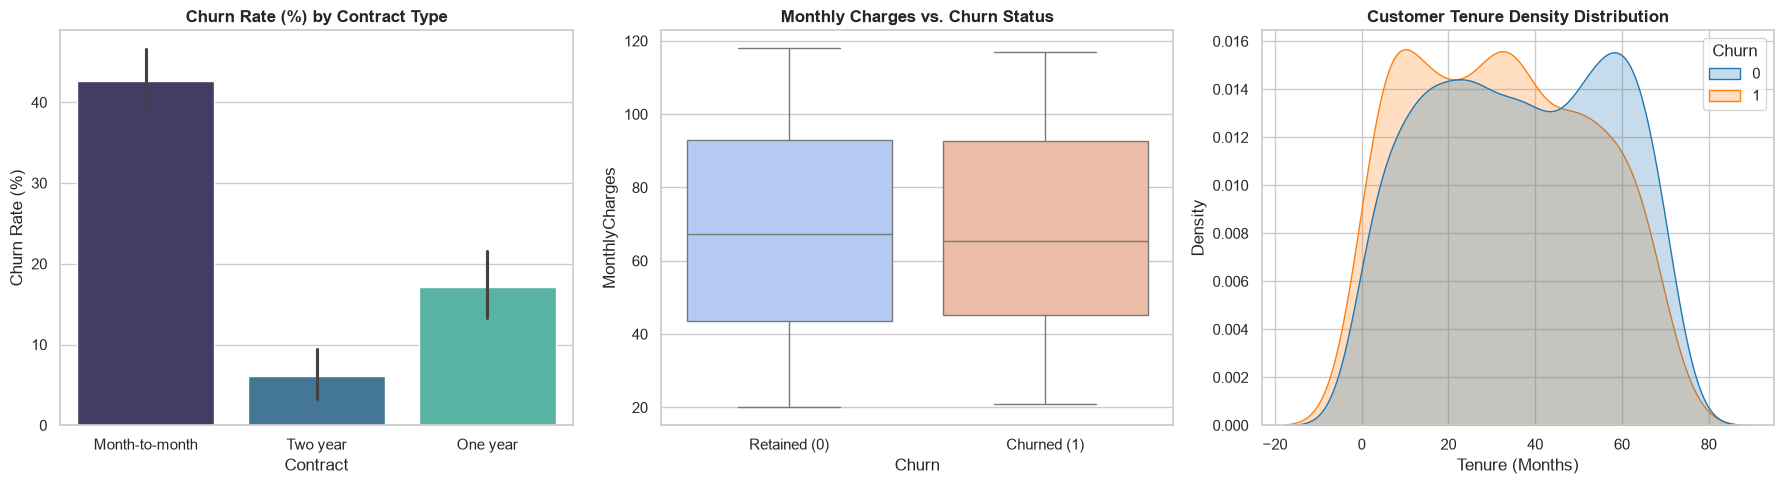


--- Model Evaluation ---
ROC-AUC Score: 0.7027

Classification Report:
              precision    recall  f1-score   support

    Retained       0.72      0.95      0.82       215
     Churned       0.38      0.07      0.12        85

    accuracy                           0.70       300
   macro avg       0.55      0.51      0.47       300
weighted avg       0.62      0.70      0.62       300

--- Top 5 Predictive Factors ---
TotalCharges         0.208846
Contract_Two year    0.200360
MonthlyCharges       0.189441
Tenure_Months        0.179045
Contract_One year    0.095712
dtype: float64


In [2]:
# ==========================================================
# MODULE 5: DATA SCIENCE MINI PROJECT - TELCO CHURN ANALYSIS
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

# 1. Dataset Generation (Synthesizing Kaggle Telco Churn Schema)
np.random.seed(42)
n_records = 1200

tenure = np.random.randint(1, 72, size=n_records)
contract = np.random.choice(["Month-to-month", "One year", "Two year"], size=n_records, p=[0.55, 0.25, 0.20])
internet_service = np.random.choice(["DSL", "Fiber optic", "No"], size=n_records, p=[0.40, 0.45, 0.15])
tech_support = np.random.choice(["Yes", "No"], size=n_records, p=[0.35, 0.65])
monthly_charges = np.random.uniform(20.0, 118.0, size=n_records).round(2)

# Churn probability driven by contract type, fiber optic service, and tenure
churn_prob = (
    0.25
    + (contract == "Month-to-month") * 0.30
    - (contract == "Two year") * 0.20
    + (internet_service == "Fiber optic") * 0.15
    - (tenure / 72.0) * 0.25
    - (tech_support == "Yes") * 0.10
).clip(0.05, 0.90)

churn = np.random.binomial(1, churn_prob)

df = pd.DataFrame({
    "CustomerID": [f"CUST-{i:04d}" for i in range(1, n_records + 1)],
    "Tenure_Months": tenure,
    "Contract": contract,
    "InternetService": internet_service,
    "TechSupport": tech_support,
    "MonthlyCharges": monthly_charges,
    "TotalCharges": (tenure * monthly_charges + np.random.normal(0, 15, size=n_records)).round(2),
    "Churn": churn
})

# 2. Exploratory Data Analysis & Insights
overall_churn_rate = df["Churn"].mean() * 100
contract_churn = df.groupby("Contract")["Churn"].mean() * 100

print(f"Overall Customer Churn Rate: {overall_churn_rate:.2f}%")
print("\n--- Churn Rate by Contract Type ---")
print(contract_churn)

# 3. Multi-Plot Insight Visualizations
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Churn Rate by Contract Type
sns.barplot(
    x="Contract", 
    y="Churn", 
    data=df, 
    palette="mako", 
    ax=axes[0], 
    estimator=lambda x: np.mean(x) * 100
)
axes[0].set_title("Churn Rate (%) by Contract Type", fontweight="bold")
axes[0].set_ylabel("Churn Rate (%)")

# Plot B: Monthly Charges Distribution by Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="coolwarm", ax=axes[1])
axes[1].set_title("Monthly Charges vs. Churn Status", fontweight="bold")
axes[1].set_xticklabels(["Retained (0)", "Churned (1)"])

# Plot C: Tenure vs Churn KDE
sns.kdeplot(data=df, x="Tenure_Months", hue="Churn", common_norm=False, fill=True, palette="tab10", ax=axes[2])
axes[2].set_title("Customer Tenure Density Distribution", fontweight="bold")
axes[2].set_xlabel("Tenure (Months)")

plt.tight_layout()
plt.show()

# 4. Feature Engineering & Predictive Modeling
X = pd.get_dummies(df.drop(columns=["CustomerID", "Churn"]), drop_first=True)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

y_preds = rf.predict(X_test)
roc_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print("\n--- Model Evaluation ---")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_preds, target_names=["Retained", "Churned"]))

# Feature Importance Ranking
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("--- Top 5 Predictive Factors ---")
print(importances.head(5))